<a href="https://colab.research.google.com/github/Syeda-Rb-47/Building-GlueScore--An-Interpretable-Glue-Likeness-Scoring-Pipeline/blob/main/4_Chemical_Space_Characterization_and_Group_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORTS

In [ ]:
# Installing UMAP and importing required libraries.
!pip install -q umap-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.stats.multitest import multipletests
import umap
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Defining dataset path and thresholds for correlation and separation checks.
DRIVE_DIR        = "/content/drive/MyDrive/Thesis Datasets"
CORR_THRESHOLD   = 0.85
P_THRESHOLD      = 0.05
EFFECT_THRESHOLD = 0.3  # decided after exploring distribution in Cell 5
FINAL_CORR_THRESHOLD = 0.7

In [ ]:
# Loading the dataset.
df = pd.read_csv(DRIVE_DIR + "/descriptor_matrix.csv")

# Identifying descriptor columns (all columns except metadata columns).
meta_cols = ["Master_ID", "Source_ID", "Label", "Canonical_SMILES", "StdInChIKey"]
meta_cols = [c for c in meta_cols if c in df.columns]
desc_cols = [c for c in df.columns if c not in meta_cols]

glues = df[df["Label"] == 1]
bg    = df[df["Label"] == 0]

print("Dataset loaded:", df.shape)
print("Descriptor columns:", len(desc_cols))
print(df["Label"].value_counts())

Dataset loaded: (3738, 139)
Descriptor columns: 134
Label
0    2115
1    1623
Name: count, dtype: int64


CORRELATION CHECK

In [ ]:
# Computing Spearman correlation matrix on descriptor columns only.
corr_matrix = df[desc_cols].corr(method="spearman").abs()

# Using upper triangle mask to avoid duplicate pairs.
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Finding all pairs above threshold.
corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "Descriptor_A", "level_1": "Descriptor_B", 0: "Spearman_r"})
    .query("Spearman_r > @CORR_THRESHOLD")
    .sort_values("Spearman_r", ascending=False)
    .reset_index(drop=True)
)

print("Spearman Correlation Check\n")
print("Descriptors entering:", len(desc_cols))
print("Highly correlated pairs (|r| > " + str(CORR_THRESHOLD) + "): " + str(len(corr_pairs)))
print("\nCorrelated pairs:")
print(corr_pairs.to_string(index=False))

Spearman Correlation Check

Descriptors entering: 134
Highly correlated pairs (|r| > 0.85): 183

Correlated pairs:
           Descriptor_A            Descriptor_B  Spearman_r
               fr_Ar_NH            fr_Nhpyrrole    1.000000
                  MolWt              ExactMolWt    0.999993
                  MolWt          HeavyAtomMolWt    0.998492
                   Chi1          HeavyAtomCount    0.998451
         HeavyAtomMolWt              ExactMolWt    0.998411
                   Chi1                     Ipc    0.997829
                   Chi0          HeavyAtomCount    0.996223
    NumValenceElectrons                    Chi0    0.995922
              LabuteASA          HeavyAtomCount    0.995079
                    Ipc          HeavyAtomCount    0.994730
    NumValenceElectrons          HeavyAtomCount    0.994405
                   Chi1               LabuteASA    0.993840
    NumValenceElectrons               LabuteASA    0.992578
                  Chi0v               LabuteA

In [ ]:
# Tracing which descriptors are to be dropped
to_drop_trace = set()
decisions = []

for _, row in corr_pairs.iterrows():
    a = row["Descriptor_A"]
    b = row["Descriptor_B"]

    if a in to_drop_trace:
        decisions.append("Skip")        # A already dropped so skip entire pair
    elif b in to_drop_trace:
        decisions.append("None")        # B already dropped so do nothing
    else:
        to_drop_trace.add(b)            # Neither dropped yet so keep A and drop B
        decisions.append("Drop_B")

corr_pairs["Decision"] = decisions

print("Correlation Drop Trace\n")
print(corr_pairs.to_string(index=False))
print("\nTotal pairs:", len(corr_pairs))
print("Drop_B:", decisions.count('Drop_B'))
print("Skip:", decisions.count('Skip'))
print("None:", decisions.count('None'))
print("\nDescriptors to be dropped:", len(to_drop_trace))

Correlation Drop Trace

           Descriptor_A            Descriptor_B  Spearman_r Decision
               fr_Ar_NH            fr_Nhpyrrole    1.000000   Drop_B
                  MolWt              ExactMolWt    0.999993   Drop_B
                  MolWt          HeavyAtomMolWt    0.998492   Drop_B
                   Chi1          HeavyAtomCount    0.998451   Drop_B
         HeavyAtomMolWt              ExactMolWt    0.998411     Skip
                   Chi1                     Ipc    0.997829   Drop_B
                   Chi0          HeavyAtomCount    0.996223     None
    NumValenceElectrons                    Chi0    0.995922   Drop_B
              LabuteASA          HeavyAtomCount    0.995079     None
                    Ipc          HeavyAtomCount    0.994730     Skip
    NumValenceElectrons          HeavyAtomCount    0.994405     None
                   Chi1               LabuteASA    0.993840   Drop_B
    NumValenceElectrons               LabuteASA    0.992578     None
          

In [ ]:
# Dropping correlated descriptors but keeping the interpretable ones over non-interpretable ones.
# Automatically dropping the second descriptor in each correlated pair.
to_drop = set()
for _, row in corr_pairs.iterrows():
    # If neither has been dropped yet, drop B.
    if row["Descriptor_A"] not in to_drop and row["Descriptor_B"] not in to_drop:
        to_drop.add(row["Descriptor_B"])

# Manually overriding to replace BalabanJ (graph-theory index) with RingCount (directly countable) to preserve interpretability.
to_drop.discard("RingCount")
to_drop.add("BalabanJ")

desc_cols_uncorr = [c for c in desc_cols if c not in to_drop]

print("Descriptors before correlation filter :", len(desc_cols))
print("Descriptors dropped                   :", len(to_drop))
print("Descriptors remaining                 :", len(desc_cols_uncorr))
print("\nDropped descriptors:", sorted(to_drop))

Descriptors before correlation filter : 134
Descriptors dropped                   : 35
Descriptors remaining                 : 99

Dropped descriptors: ['BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2v', 'Chi4v', 'ExactMolWt', 'FpDensityMorgan2', 'HeavyAtomCount', 'HeavyAtomMolWt', 'Ipc', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'MolMR', 'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms', 'NumSaturatedCarbocycles', 'NumValenceElectrons', 'Phi', 'SlogP_VSA6', 'VSA_EState10', 'VSA_EState6', 'fr_Ar_N', 'fr_Nhpyrrole', 'fr_phenol', 'fr_phenol_noOrthoHbond']


SEPARATION CHECK

In [ ]:
# Running Mann-Whitney U test and computing rank-biserial correlation as effect size for each descriptor between glues and background.

def rank_biserial(u_stat, n1, n2):
    return (2 * u_stat) / (n1 * n2) - 1

n_glue = len(glues)
n_bg   = len(bg)

sep_results = []

for desc in desc_cols_uncorr:
    g_vals           = glues[desc].values
    b_vals           = bg[desc].values
    u_stat, p_val    = stats.mannwhitneyu(g_vals, b_vals, alternative="two-sided")
    r                = rank_biserial(u_stat, n_glue, n_bg)

    sep_results.append({
        "Descriptor" : desc,
        "p_value"    : round(p_val, 4),
        "effect_size": round(r, 4),
        "direction"  : "Glues_Higher" if r > 0 else "Glues_Lower"
    })

sep_df = pd.DataFrame(sep_results).sort_values("effect_size", key=abs, ascending=False).reset_index(drop=True)

print("Total descriptors tested:", len(sep_df))
print("\nTop 10 by effect size:")
print(sep_df.head(10).to_string(index=False))

Total descriptors tested: 99

Top 10 by effect size:
     Descriptor  p_value  effect_size    direction
     PEOE_VSA12      0.0       0.7166 Glues_Higher
  HallKierAlpha      0.0      -0.6597  Glues_Lower
    VSA_EState2      0.0       0.6590 Glues_Higher
       SMR_VSA3      0.0       0.6577 Glues_Higher
         fr_NH1      0.0       0.6442 Glues_Higher
NumHeterocycles      0.0       0.6092 Glues_Higher
      SMR_VSA10      0.0       0.5782 Glues_Higher
        NOCount      0.0       0.5395 Glues_Higher
      RingCount      0.0       0.5334 Glues_Higher
         AvgIpc      0.0       0.4925 Glues_Higher


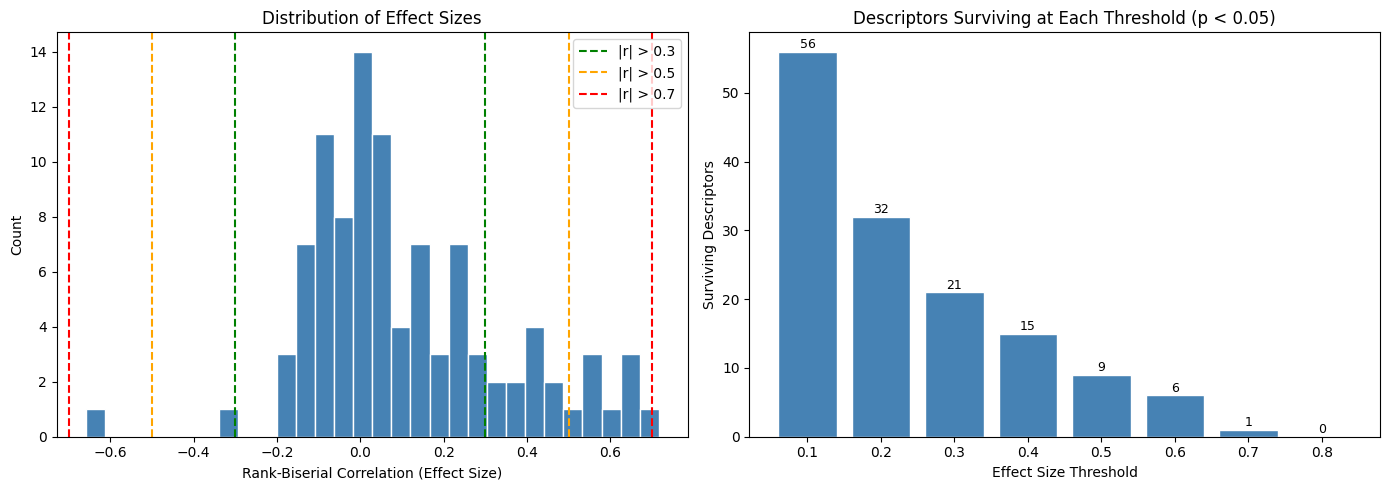


Surviving descriptors at each threshold (p < 0.05):
  |r| > 0.1: 56 descriptors
  |r| > 0.2: 32 descriptors
  |r| > 0.3: 21 descriptors
  |r| > 0.4: 15 descriptors
  |r| > 0.5: 9 descriptors
  |r| > 0.6: 6 descriptors
  |r| > 0.7: 1 descriptors
  |r| > 0.8: 0 descriptors


In [ ]:
# Plotting effect size distribution and survival counts at different thresholds to decide the best EFFECT_THRESHOLD value.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Effect size distribution
axes[0].hist(sep_df["effect_size"], bins=30, color="steelblue", edgecolor="white")
for thresh, color in [(0.3, "green"), (0.5, "orange"), (0.7, "red")]:
    axes[0].axvline( thresh, color=color, linestyle="--", label=f"|r| > {thresh}")
    axes[0].axvline(-thresh, color=color, linestyle="--")
axes[0].set_xlabel("Rank-Biserial Correlation (Effect Size)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Effect Sizes")
axes[0].legend()

# Surviving descriptor counts at each threshold
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
counts     = []
for t in thresholds:
    n = len(sep_df[(sep_df["effect_size"].abs() > t) & (sep_df["p_value"] < P_THRESHOLD)])
    counts.append(n)

axes[1].bar([str(t) for t in thresholds], counts, color="steelblue", edgecolor="white")
for i, c in enumerate(counts):
    axes[1].text(i, c + 0.5, str(c), ha="center", fontsize=9)
axes[1].set_xlabel("Effect Size Threshold")
axes[1].set_ylabel("Surviving Descriptors")
axes[1].set_title("Descriptors Surviving at Each Threshold (p < 0.05)")

plt.tight_layout()
plt.savefig(DRIVE_DIR + "/threshold_exploration.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSurviving descriptors at each threshold (p < 0.05):")
for t, c in zip(thresholds, counts):
    print(f"  |r| > {t}: {c} descriptors")

In [ ]:
# Updated EFFECT_THRESHOLD in Cell 2 based on the exploration above and then ran this cell.
final_desc = sep_df[
    (sep_df["effect_size"].abs() > EFFECT_THRESHOLD) &
    (sep_df["p_value"]           < P_THRESHOLD)
]["Descriptor"].tolist()

print("Final Descriptor Set\n")
print("Threshold used:", EFFECT_THRESHOLD)
print("Descriptors surviving:", len(final_desc))
print("\nFinal descriptors:")
print(sep_df[sep_df["Descriptor"].isin(final_desc)][
    ["Descriptor", "effect_size", "p_value", "direction"]
].to_string(index=False))

Final Descriptor Set

Threshold used: 0.3
Descriptors surviving: 21

Final descriptors:
      Descriptor  effect_size  p_value    direction
      PEOE_VSA12       0.7166      0.0 Glues_Higher
   HallKierAlpha      -0.6597      0.0  Glues_Lower
     VSA_EState2       0.6590      0.0 Glues_Higher
        SMR_VSA3       0.6577      0.0 Glues_Higher
          fr_NH1       0.6442      0.0 Glues_Higher
 NumHeterocycles       0.6092      0.0 Glues_Higher
       SMR_VSA10       0.5782      0.0 Glues_Higher
         NOCount       0.5395      0.0 Glues_Higher
       RingCount       0.5334      0.0 Glues_Higher
          AvgIpc       0.4925      0.0 Glues_Higher
NumAromaticRings       0.4777      0.0 Glues_Higher
      SlogP_VSA1       0.4747      0.0 Glues_Higher
       PEOE_VSA8       0.4272      0.0 Glues_Higher
           MolWt       0.4262      0.0 Glues_Higher
          fr_NH0       0.4212      0.0 Glues_Higher
        SMR_VSA7       0.4000      0.0 Glues_Higher
     EState_VSA3       0.389

In [ ]:
# Applying Benjamini-Hochberg FDR correction to p-values from Mann-Whitney tests.
# BH correction controls the false discovery rate across multiple simultaneous tests.
reject, p_corrected, _, _ = multipletests(sep_df["p_value"], method="fdr_bh")
sep_df["p_corrected"] = p_corrected.round(4)
sep_df["BH_reject"]   = reject

# Comparing original vs corrected filtering
original_survivors = sep_df[
    (sep_df["p_value"]     < P_THRESHOLD) &
    (sep_df["effect_size"].abs() > EFFECT_THRESHOLD)
]["Descriptor"].tolist()

corrected_survivors = sep_df[
    (sep_df["p_corrected"] < P_THRESHOLD) &
    (sep_df["effect_size"].abs() > EFFECT_THRESHOLD)
]["Descriptor"].tolist()

dropped_after_correction = [d for d in original_survivors if d not in corrected_survivors]
newly_added              = [d for d in corrected_survivors if d not in original_survivors]

print("Benjamini-Hochberg FDR Correction\n")
print("Descriptors surviving original p < 0.05 and effect size threshold    :", len(original_survivors))
print("Descriptors surviving BH corrected p < 0.05 and effect size threshold:", len(corrected_survivors))
print("\nDropped after BH correction:", dropped_after_correction if dropped_after_correction else "None")
print("Newly added after BH correction:", newly_added if newly_added else "None")

print("\nDescriptors with corrected p-values:")
print(sep_df.sort_values("effect_size", key=abs, ascending=False)[
    ["Descriptor", "p_value", "p_corrected", "effect_size", "BH_reject"]
].to_string(index=False))

Benjamini-Hochberg FDR Correction

Descriptors surviving original p < 0.05 and effect size threshold    : 21
Descriptors surviving BH corrected p < 0.05 and effect size threshold: 21

Dropped after BH correction: None
Newly added after BH correction: None

Descriptors with corrected p-values:
             Descriptor  p_value  p_corrected  effect_size  BH_reject
             PEOE_VSA12   0.0000       0.0000       0.7166       True
          HallKierAlpha   0.0000       0.0000      -0.6597       True
            VSA_EState2   0.0000       0.0000       0.6590       True
               SMR_VSA3   0.0000       0.0000       0.6577       True
                 fr_NH1   0.0000       0.0000       0.6442       True
        NumHeterocycles   0.0000       0.0000       0.6092       True
              SMR_VSA10   0.0000       0.0000       0.5782       True
                NOCount   0.0000       0.0000       0.5395       True
              RingCount   0.0000       0.0000       0.5334       True
      

In [ ]:
# Checking contribution of each filter independently.
print("Separation Check Results\n")
print("Total descriptors tested  :", len(sep_df))
print("Fails p-value only        :", len(sep_df[sep_df['p_value'] >= P_THRESHOLD]))
print("Fails effect size only    :", len(sep_df[sep_df['effect_size'].abs() <= EFFECT_THRESHOLD]))
print("Survives both filters     :", len(final_desc))

Separation Check Results

Total descriptors tested  : 99
Fails p-value only        : 18
Fails effect size only    : 78
Survives both filters     : 21


DISTRIBUTION AND SPACE VISUALIZATION

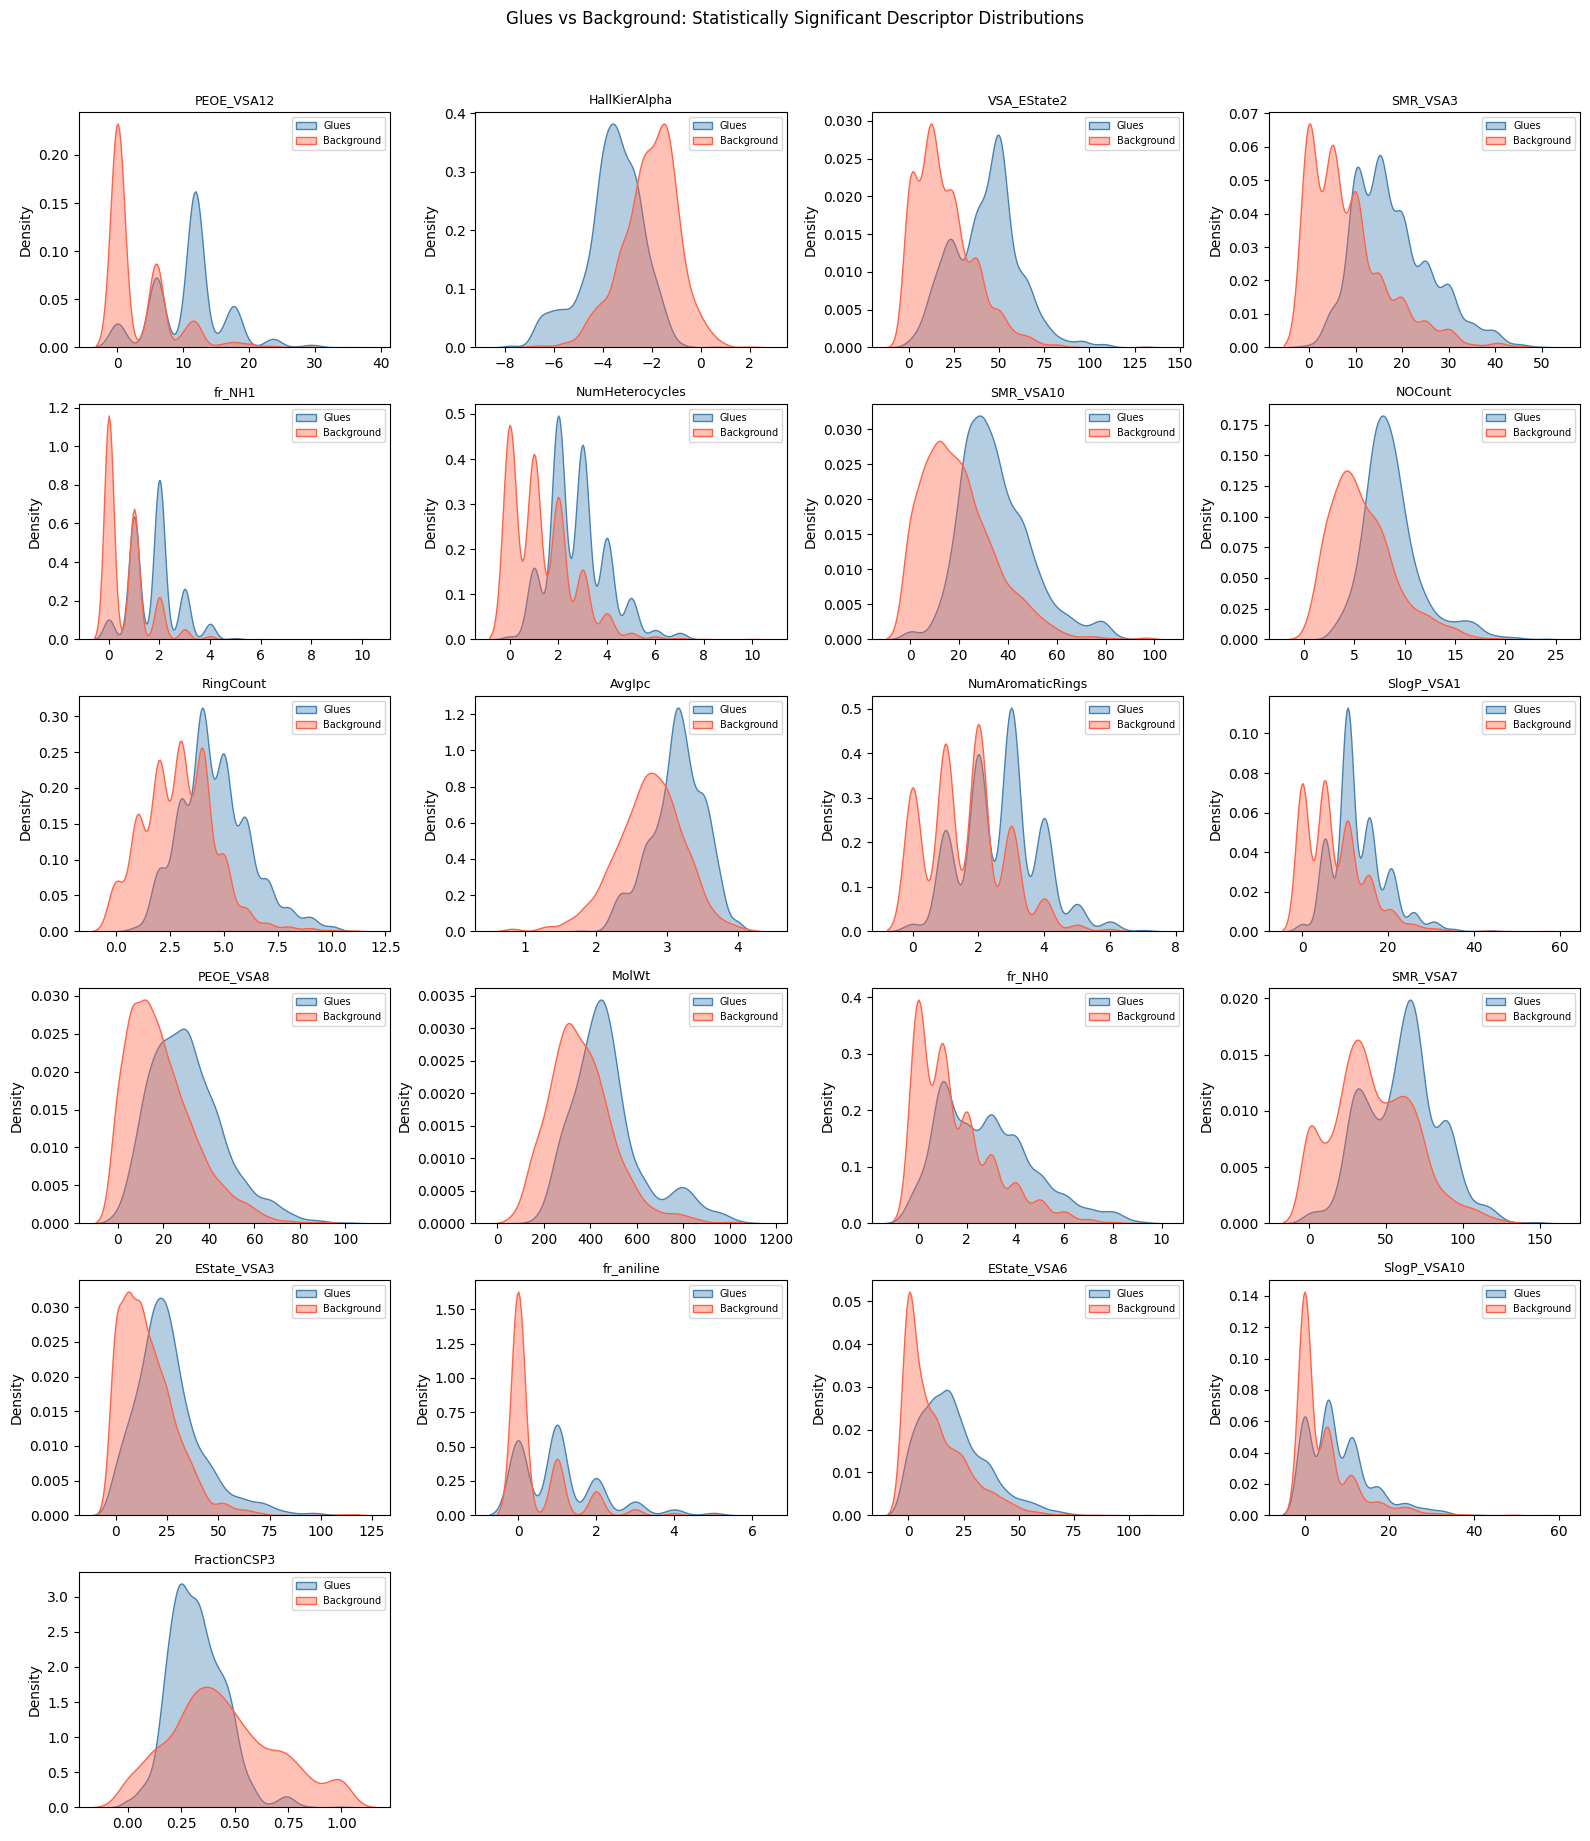

In [ ]:
# Plotting KDE distributions of glues vs background for each surviving descriptor.
n_cols = 4
n_rows = int(np.ceil(len(final_desc) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes      = axes.flatten()

for i, desc in enumerate(final_desc):
    ax = axes[i]
    sns.kdeplot(glues[desc], ax=ax, label="Glues",      color="steelblue", fill=True, alpha=0.4)
    sns.kdeplot(bg[desc],    ax=ax, label="Background", color="tomato",    fill=True, alpha=0.4)
    ax.set_title(desc, fontsize=9)
    ax.set_xlabel("")
    ax.legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Glues vs Background: Statistically Significant Descriptor Distributions", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(DRIVE_DIR + "/descriptor_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

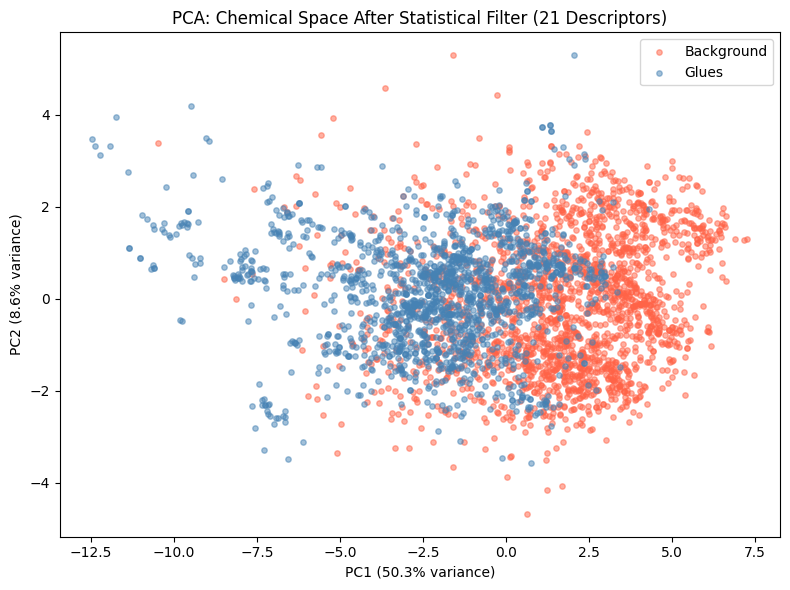

PC1: 50.3 % variance
PC2: 8.6 % variance
Combined: 58.9 %


In [ ]:
# Standardizing descriptor values and applying PCA to visualize chemical space.
scaler     = StandardScaler()
scaled_21     = scaler.fit_transform(df[final_desc].values)

pca        = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(scaled_21)

pca_df           = pd.DataFrame(pca_coords, columns=["PC1", "PC2"])
pca_df["Label"]  = df["Label"].values

fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in [(0, "tomato", "Background"), (1, "steelblue", "Glues")]:
    mask = pca_df["Label"] == label
    ax.scatter(pca_df.loc[mask, "PC1"], pca_df.loc[mask, "PC2"],
               c=color, label=name, alpha=0.5, s=15)

ax.set_xlabel("PC1 (" + str(round(pca.explained_variance_ratio_[0]*100, 1)) + "% variance)")
ax.set_ylabel("PC2 (" + str(round(pca.explained_variance_ratio_[1]*100, 1)) + "% variance)")
ax.set_title("PCA: Chemical Space After Statistical Filter (21 Descriptors)")
ax.legend()
plt.tight_layout()
plt.savefig(DRIVE_DIR + "/pca_plot_21.png", dpi=150, bbox_inches="tight")
plt.show()

print("PC1:", round(pca.explained_variance_ratio_[0]*100, 1), "% variance")
print("PC2:", round(pca.explained_variance_ratio_[1]*100, 1), "% variance")
print("Combined:", round(sum(pca.explained_variance_ratio_[:2])*100, 1), "%")

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


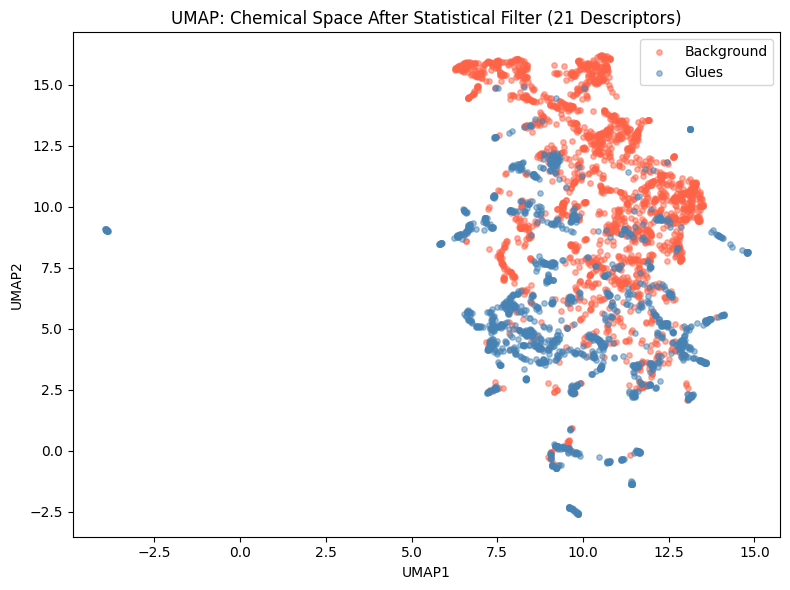

In [ ]:
# Applying UMAP on the same standardized descriptor values.
reducer     = umap.UMAP(n_components=2, random_state=42)
umap_coords = reducer.fit_transform(scaled_21)

umap_df          = pd.DataFrame(umap_coords, columns=["UMAP1", "UMAP2"])
umap_df["Label"] = df["Label"].values

fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in [(0, "tomato", "Background"), (1, "steelblue", "Glues")]:
    mask = umap_df["Label"] == label
    ax.scatter(umap_df.loc[mask, "UMAP1"], umap_df.loc[mask, "UMAP2"],
               c=color, label=name, alpha=0.5, s=15)

ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("UMAP: Chemical Space After Statistical Filter (21 Descriptors)")
ax.legend()
plt.tight_layout()
plt.savefig(DRIVE_DIR + "/umap_plot_21.png", dpi=150, bbox_inches="tight")
plt.show()

INTERPRETABILITY FILTER

In [ ]:
# Descriptors are retained based on direct chemical interpretability.
# Each must be explainable to a chemist without mathematical derivation.

interpretable_desc = [
          "fr_NH1",   # Counts secondary amines (NH groups)
 "NumHeterocycles",   # Counts heterocyclic rings
         "NOCount",   # Counts nitrogen and oxygen atoms
       "RingCount",   # Total number of rings
"NumAromaticRings",   # Counts aromatic rings
           "MolWt",   # Sum of the atomic weights of all atoms in a molecule
          "fr_NH0",   # Counts tertiary amines
      "fr_aniline",   # Counts aniline groups
    "FractionCSP3",   # Ratio of sp3 carbons to total carbons
]

removed_for_interpretability = [d for d in final_desc if d not in interpretable_desc]

print("Interpretability Filter\n")
print("Descriptors entering:", len(final_desc))
print("Retained descriptors:", len(interpretable_desc))
print("Removed descriptors:", len(removed_for_interpretability))
print("\nRemoved descriptors  :", removed_for_interpretability)

Interpretability Filter

Descriptors entering: 21
Retained descriptors: 9
Removed descriptors: 12

Removed descriptors  : ['PEOE_VSA12', 'HallKierAlpha', 'VSA_EState2', 'SMR_VSA3', 'SMR_VSA10', 'AvgIpc', 'SlogP_VSA1', 'PEOE_VSA8', 'SMR_VSA7', 'EState_VSA3', 'EState_VSA6', 'SlogP_VSA10']


In [ ]:
# Separation Results for Interpretable Descriptors.

final_stats = sep_df[sep_df["Descriptor"].isin(interpretable_desc)][
    ["Descriptor", "effect_size", "p_value", "direction"]
].sort_values("effect_size", key=abs, ascending=False).reset_index(drop=True)

print("Interpretable Descriptor Set\n")
print(final_stats.to_string(index=False))

Interpretable Descriptor Set

      Descriptor  effect_size  p_value    direction
          fr_NH1       0.6442      0.0 Glues_Higher
 NumHeterocycles       0.6092      0.0 Glues_Higher
         NOCount       0.5395      0.0 Glues_Higher
       RingCount       0.5334      0.0 Glues_Higher
NumAromaticRings       0.4777      0.0 Glues_Higher
           MolWt       0.4262      0.0 Glues_Higher
          fr_NH0       0.4212      0.0 Glues_Higher
      fr_aniline       0.3878      0.0 Glues_Higher
    FractionCSP3      -0.3088      0.0  Glues_Lower


FINAL DESCRIPTOR CORRELATION CHECK

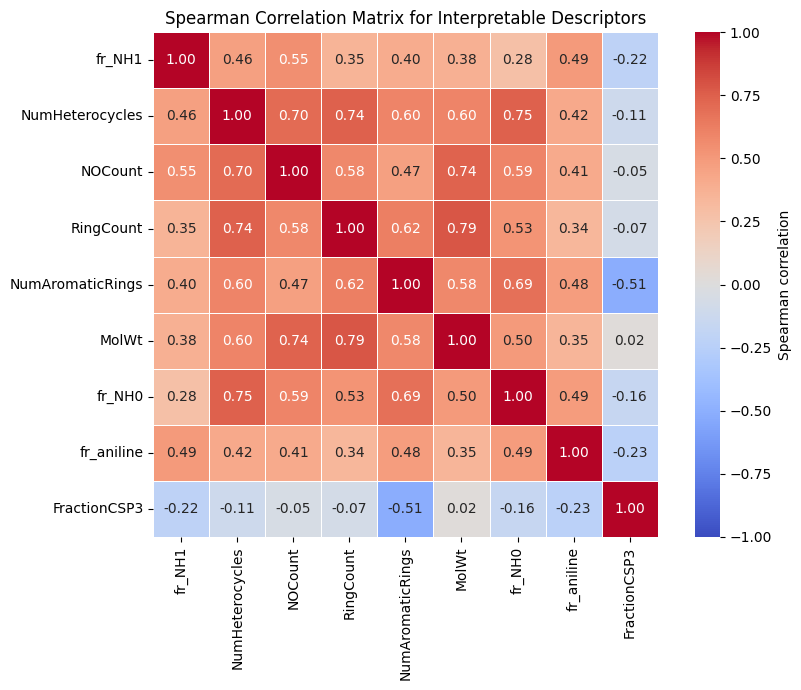

Final Descriptor Correlation Check

Method    : Spearman
Threshold : 0.7

Flagged pairs:
   Descriptor_1 Descriptor_2  Spearman_r
      RingCount        MolWt       0.788
NumHeterocycles       fr_NH0       0.747
NumHeterocycles    RingCount       0.744
        NOCount        MolWt       0.742
NumHeterocycles      NOCount       0.704


In [ ]:
# Correlation check on final 9 interpretable descriptors
# Spearman correlation used for consistency with earlier correlation filter.
# Threshold: |r| > 0.7 flagged as potentially concerning.

# Compute Spearman correlation matrix
spearman_matrix = df[interpretable_desc].corr(method="spearman")

# Generating Heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(spearman_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, cbar_kws={"label": "Spearman correlation"})
plt.title("Spearman Correlation Matrix for Interpretable Descriptors")
plt.tight_layout()
plt.savefig(DRIVE_DIR + "/interpretable_descriptor_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

# Flag pairs above threshold
flagged_pairs = []

for i in range(len(interpretable_desc)):
    for j in range(i + 1, len(interpretable_desc)):
        d1 = interpretable_desc[i]
        d2 = interpretable_desc[j]
        rs = spearman_matrix.iloc[i, j]
        if abs(rs) > FINAL_CORR_THRESHOLD:
            flagged_pairs.append({"Descriptor_1": d1, "Descriptor_2": d2, "Spearman_r": round(rs, 3)})

flagged_df = pd.DataFrame(flagged_pairs).sort_values("Spearman_r", key=abs, ascending=False) if flagged_pairs else pd.DataFrame()

print("Final Descriptor Correlation Check\n")
print("Method    : Spearman")
print("Threshold :", FINAL_CORR_THRESHOLD)
print("\nFlagged pairs:")
print(flagged_df.to_string(index=False) if not flagged_df.empty else "None — all descriptor pairs below threshold. Final 9 descriptors confirmed as non-redundant.")

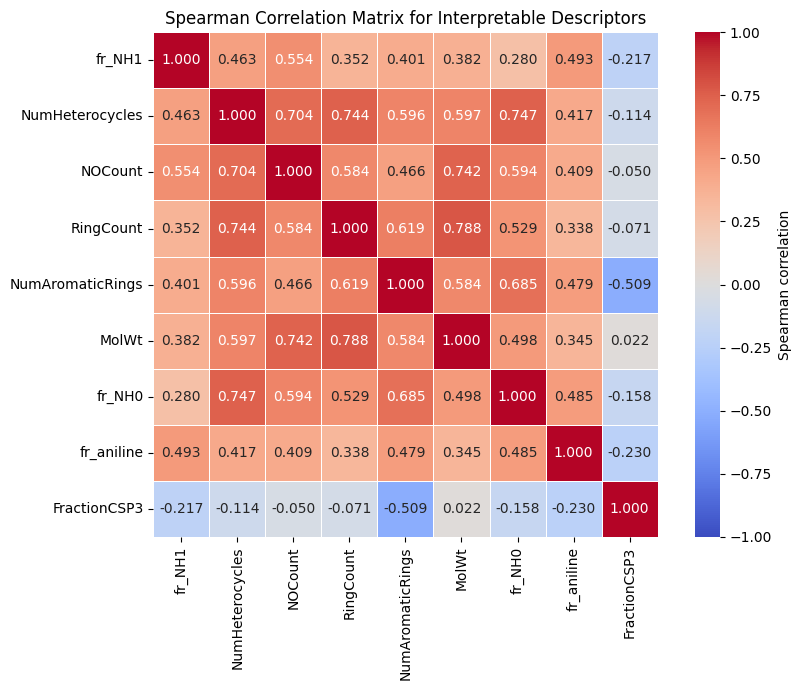

Final Descriptor Correlation Check

Method    : Spearman
Threshold : 0.7

Flagged pairs:
   Descriptor_1 Descriptor_2  Spearman_r
      RingCount        MolWt       0.788
NumHeterocycles       fr_NH0       0.747
NumHeterocycles    RingCount       0.744
        NOCount        MolWt       0.742
NumHeterocycles      NOCount       0.704


In [ ]:
# Correlation check on final 9 interpretable descriptors
# Spearman correlation used for consistency with earlier correlation filter.
# Threshold: |r| > 0.7 flagged as potentially concerning.

# Compute Spearman correlation matrix
spearman_matrix = df[interpretable_desc].corr(method="spearman")

# Generating Heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(spearman_matrix, annot=True, fmt=".3f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, cbar_kws={"label": "Spearman correlation"})
plt.title("Spearman Correlation Matrix for Interpretable Descriptors")
plt.tight_layout()
plt.savefig(DRIVE_DIR + "/interpretable_descriptor_correlation_3decimalplaces.png", dpi=150, bbox_inches="tight")
plt.show()

# Flag pairs above threshold
flagged_pairs = []

for i in range(len(interpretable_desc)):
    for j in range(i + 1, len(interpretable_desc)):
        d1 = interpretable_desc[i]
        d2 = interpretable_desc[j]
        rs = spearman_matrix.iloc[i, j]
        if abs(rs) > FINAL_CORR_THRESHOLD:
            flagged_pairs.append({"Descriptor_1": d1, "Descriptor_2": d2, "Spearman_r": round(rs, 3)})

flagged_df = pd.DataFrame(flagged_pairs).sort_values("Spearman_r", key=abs, ascending=False) if flagged_pairs else pd.DataFrame()

print("Final Descriptor Correlation Check\n")
print("Method    : Spearman")
print("Threshold :", FINAL_CORR_THRESHOLD)
print("\nFlagged pairs:")
print(flagged_df.to_string(index=False) if not flagged_df.empty else "None — all descriptor pairs below threshold. Final 9 descriptors confirmed as non-redundant.")

In [ ]:
# MolWt removed as it correlates with RingCount (r=0.788) exceeding 0.75 threshold and has lower effect size than RingCount.
# fr_NH0 removed as it has lowest effect size (0.4212) in correlated cluster shared with NumHeterocycles.

interpretable_desc = [d for d in interpretable_desc if d not in ["MolWt", "fr_NH0"]]

print("Final descriptor set:", interpretable_desc)
print("Total descriptors   :", len(interpretable_desc))

Final descriptor set: ['fr_NH1', 'NumHeterocycles', 'NOCount', 'RingCount', 'NumAromaticRings', 'fr_aniline', 'FractionCSP3']
Total descriptors   : 7


FINAL CHEMICAL SPACE VISUALIZATION

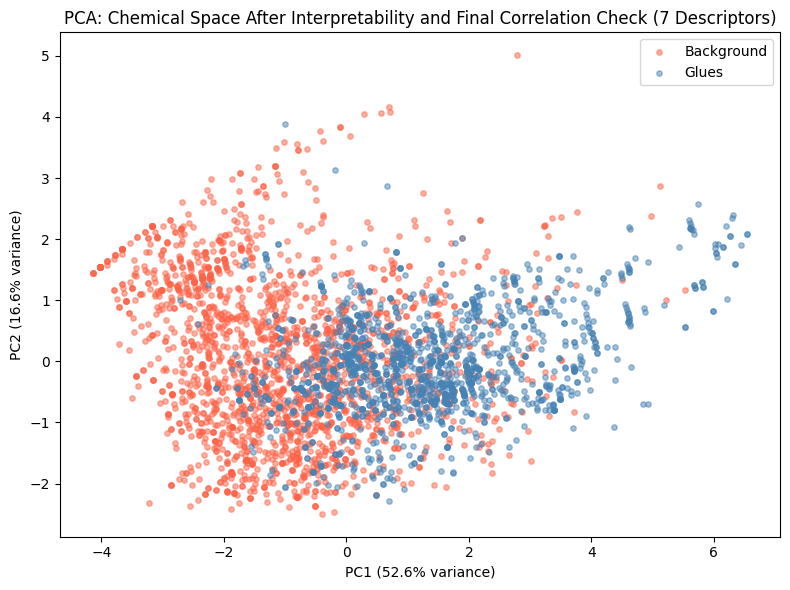

PC1: 52.6 % variance
PC2: 16.6 % variance
Combined: 69.2 %


In [ ]:
# Standardizing the final descriptor values and applying PCA to visualize chemical space.
scaler     = StandardScaler()
scaled_9     = scaler.fit_transform(df[interpretable_desc].values)

pca        = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(scaled_9)

pca_df           = pd.DataFrame(pca_coords, columns=["PC1", "PC2"])
pca_df["Label"]  = df["Label"].values

fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in [(0, "tomato", "Background"), (1, "steelblue", "Glues")]:
    mask = pca_df["Label"] == label
    ax.scatter(pca_df.loc[mask, "PC1"], pca_df.loc[mask, "PC2"],
               c=color, label=name, alpha=0.5, s=15)

ax.set_xlabel("PC1 (" + str(round(pca.explained_variance_ratio_[0]*100, 1)) + "% variance)")
ax.set_ylabel("PC2 (" + str(round(pca.explained_variance_ratio_[1]*100, 1)) + "% variance)")
ax.set_title("PCA: Chemical Space After Interpretability and Final Correlation Check (7 Descriptors)")
ax.legend()
plt.tight_layout()
plt.savefig(DRIVE_DIR + "/pca_plot_7.png", dpi=150, bbox_inches="tight")
plt.show()

print("PC1:", round(pca.explained_variance_ratio_[0]*100, 1), "% variance")
print("PC2:", round(pca.explained_variance_ratio_[1]*100, 1), "% variance")
print("Combined:", round(sum(pca.explained_variance_ratio_[:2])*100, 1), "%")

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


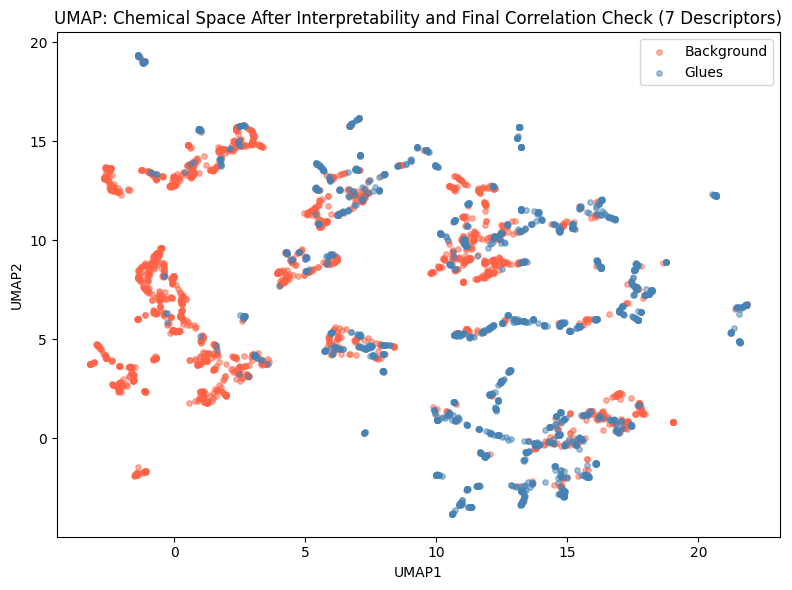

In [ ]:
# Applying UMAP on the 7 final descriptor values.
reducer     = umap.UMAP(n_components=2, random_state=42)
umap_coords = reducer.fit_transform(scaled_9)

umap_df          = pd.DataFrame(umap_coords, columns=["UMAP1", "UMAP2"])
umap_df["Label"] = df["Label"].values

fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in [(0, "tomato", "Background"), (1, "steelblue", "Glues")]:
    mask = umap_df["Label"] == label
    ax.scatter(umap_df.loc[mask, "UMAP1"], umap_df.loc[mask, "UMAP2"],
               c=color, label=name, alpha=0.5, s=15)

ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("UMAP: Chemical Space After Interpretability and Final Correlation Check (7 Descriptors)")
ax.legend()
plt.tight_layout()
plt.savefig(DRIVE_DIR + "/umap_plot_7.png", dpi=150, bbox_inches="tight")
plt.show()

SAVING OUTPUTS

In [ ]:
# Saving the metadata columns and the final 7 interpretable descriptors.
meta_to_keep    = [c for c in ["Master_ID", "Source_ID", "Label", "Canonical_SMILES", "StdInChIKey"] if c in df.columns]
final_matrix_df = df[meta_to_keep + interpretable_desc].copy()

# Separation stats for the 7 interpretable descriptors only.
final_stats_df  = sep_df[sep_df["Descriptor"].isin(interpretable_desc)][
    ["Descriptor", "effect_size", "p_value", "direction"]
].sort_values("effect_size", key=abs, ascending=False).reset_index(drop=True)

# Saving results in DRIVE.
sep_df.to_csv(DRIVE_DIR + "/separation_results_all.csv",   index=False)
final_stats_df.to_csv(DRIVE_DIR + "/separation_results_final7.csv", index=False)
final_matrix_df.to_csv(DRIVE_DIR + "/final_descriptor_matrix.csv",  index=False)

print("Full separation results saved to   : separation_results_all.csv")
print("Final 7 descriptor stats saved to  : separation_results_final7.csv")
print("Final descriptor matrix saved to   : final_descriptor_matrix.csv")
print("\nFinal descriptor matrix shape   :", final_matrix_df.shape)
print("Descriptors carried to Step 5   :", interpretable_desc)

Full separation results saved to   : separation_results_all.csv
Final 7 descriptor stats saved to  : separation_results_final7.csv
Final descriptor matrix saved to   : final_descriptor_matrix.csv

Final descriptor matrix shape   : (3738, 12)
Descriptors carried to Step 5   : ['fr_NH1', 'NumHeterocycles', 'NOCount', 'RingCount', 'NumAromaticRings', 'fr_aniline', 'FractionCSP3']


SUMMARY

In [ ]:
print("Summary of Results\n")

print("Descriptors loaded from dataset :", len(desc_cols))
print("After correlation filter (r>0.85) :", len(desc_cols_uncorr))
print("After Mann-Whitney (p<0.05) :", len(sep_df[sep_df['p_value'] < P_THRESHOLD]))
print("After effect size (|r|>", EFFECT_THRESHOLD, "):  ", len(final_desc))
print("After interpretability filter :", len(interpretable_desc) + 2)
print("After final correlation check (r>0.75) :", len(interpretable_desc))

Summary of Results

Descriptors loaded from dataset : 134
After correlation filter (r>0.85) : 99
After Mann-Whitney (p<0.05) : 81
After effect size (|r|> 0.3 ):   21
After interpretability filter : 9
After final correlation check (r>0.75) : 7
